## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

Name: Ronald Celino

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

alc = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

In [73]:
alc.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


In [74]:
alc.tail()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5
192,Zimbabwe,64,18,4,4.7


In [75]:
alc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    object 
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 7.7+ KB


## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [76]:
# dropped total litres of alc column and used .melt()
# put types of servings all under one column "drink"
alc_tidy = alc.drop(columns=["total_litres_of_pure_alcohol"])
alc_tidy = alc_tidy.melt(id_vars=["country"], var_name="drink", value_name="servings")
alc_tidy

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217
...,...,...,...
574,Venezuela,wine_servings,3
575,Vietnam,wine_servings,1
576,Yemen,wine_servings,0
577,Zambia,wine_servings,4


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [77]:
# removing the _servings part of the elements under the drink col
alc_tidy["drink"] = alc_tidy["drink"].str.replace("_servings", "")
alc_tidy

,country,drink,servings
0,Afghanistan,beer,0
1,Albania,beer,89
2,Algeria,beer,25
3,Andorra,beer,245
4,Angola,beer,217
...,...,...,...
574,Venezuela,wine,3
575,Vietnam,wine,1
576,Yemen,wine,0
577,Zambia,wine,4


In [78]:
top_beer = alc_tidy[alc_tidy.drink == "beer"].nlargest(10, "servings")
top_wine = alc_tidy[alc_tidy.drink == "wine"].nlargest(10, "servings")
top_spirit = alc_tidy[alc_tidy.drink == "spirit"].nlargest(10, "servings")
top_beer, top_wine, top_spirit

(            country drink  servings
 117         Namibia  beer       376
 45   Czech Republic  beer       361
 62            Gabon  beer       347
 65          Germany  beer       346
 98        Lithuania  beer       343
 135          Poland  beer       343
 188       Venezuela  beer       333
 81          Ireland  beer       313
 129           Palau  beer       306
 140         Romania  beer       297,
                country drink  servings
 447             France  wine       370
 522           Portugal  wine       339
 389            Andorra  wine       312
 552        Switzerland  wine       280
 434            Denmark  wine       278
 542           Slovenia  wine       276
 485         Luxembourg  wine       271
 428            Croatia  wine       254
 469              Italy  wine       237
 441  Equatorial Guinea  wine       233,
                 country   drink  servings
 261             Grenada  spirit       438
 208             Belarus  spirit       373
 266               Hai

Text(0.5, 1.0, 'Top 10 countries that drink the most beer')

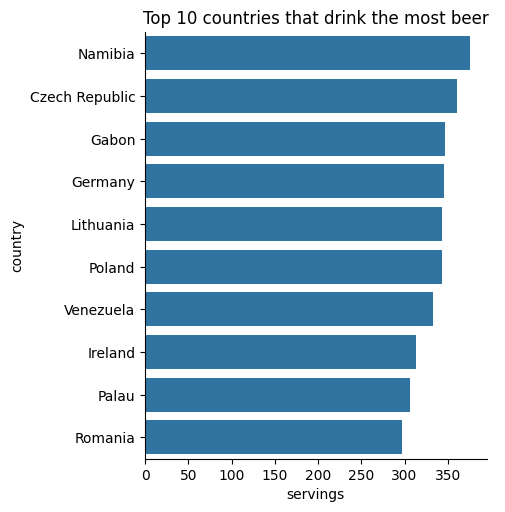

In [79]:
sns.catplot(data=top_beer, x="servings", y="country", kind="bar")
plt.title("Top 10 countries that drink the most beer")

Text(0.5, 1.0, 'Top 10 countries that drink the most wine')

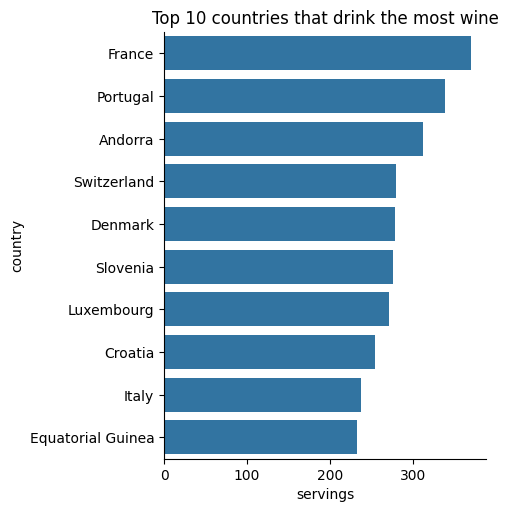

In [80]:
sns.catplot(data=top_wine, x="servings", y="country", kind="bar")
plt.title("Top 10 countries that drink the most wine")

Text(0.5, 1.0, 'Top 10 countries that drink the most spirits')

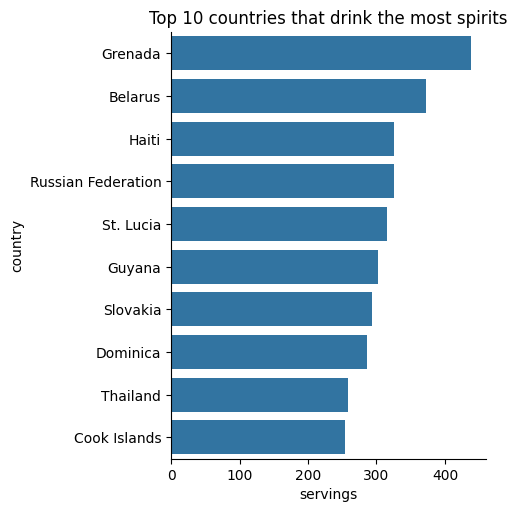

In [81]:
sns.catplot(data=top_spirit, x="servings", y="country", kind="bar")
plt.title("Top 10 countries that drink the most spirits")

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [82]:
# revert tidy dataframe from q2 back to wide using pivot table
alc_wide = alc_tidy.pivot_table(index="country", columns="drink", values="servings")
alc_wide

drink,beer,spirit,wine
country,,,
Afghanistan,0.0,0.0,0.0
Albania,89.0,132.0,54.0
Algeria,25.0,0.0,14.0
Andorra,245.0,138.0,312.0
Angola,217.0,57.0,45.0
...,...,...,...
Venezuela,333.0,100.0,3.0
Vietnam,111.0,2.0,1.0
Yemen,6.0,0.0,0.0
